# Sentenced Differently: Data Processing & Exploratory Analysis

**Project**: Racial and Gender Disparities in Federal Sentencing (FY2020-FY2024)  
**Data Source**: U.S. Sentencing Commission Individual Offender Datafiles  

This notebook walks through:
1. **Load** the cleaned, merged USSC dataset (284,823 cases)
2. **Data quality** checks and variable summaries
3. **Descriptive statistics** — sentence length by race, gender, race x gender, offense category
4. **Statistical tests** — ANOVA, Kruskal-Wallis, Chi-square
5. **Exploratory visualizations** — distributions, box plots, bar charts
6. **Summary table** formatted for the report

In [1]:
import sys, os
from pathlib import Path

# Set project root
PROJECT_ROOT = Path(os.path.abspath('')).parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

%matplotlib inline
sns.set_theme(style='whitegrid', font_scale=1.1)
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.2f}'.format)

print(f'Working directory: {os.getcwd()}')
print(f'pandas {pd.__version__}, numpy {np.__version__}')

Working directory: /Users/latahviawilliams/s26-sentenced-differently
pandas 2.3.3, numpy 2.0.2


---
## 1. Load Data

The data pipeline (`src/load_data.py`) reads FY2020-FY2024 USSC zip archives from `data/raw/`, extracts only the variables needed for analysis, recodes demographics, and saves to parquet.

To rebuild from raw data:
```python
from src.load_data import build_dataset
df = build_dataset(years=[2020, 2021, 2022, 2023, 2024])
```

In [2]:
df = pd.read_parquet(PROJECT_ROOT / 'data' / 'processed' / 'ussc_fy2020_fy2024.parquet')
print(f'Dataset: {len(df):,} cases x {len(df.columns)} variables')
print(f'Fiscal years: {sorted(df["FISCALYR"].unique())}')
df.head()

Dataset: 284,823 cases x 34 variables
Fiscal years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,ZONE,SENTTOT,SENSPLT0,USSCIDN,AGE,AGECAT,CIRCDIST,CRIMHIST,DISTRICT,EDUCATN,HISPORIG,INOUT,MONRACE,MONSEX,NEWCIT,NEWEDUC,NEWRACE,NOCOUNTS,OFFGUIDE,SENTMON,SENTRNGE,XCRHISSR,XFOLSOR,XMAXSOR,XMINSOR,FISCALYR,RACE,SEX,CRIM_HIST,OFFENSE_CAT,ZONE_LABEL,SENTENCE_TYPE,SENTENCE_MONTHS,INCARCERATED
0,NaN,6.00,6.00,2569518,23.00,2.00,2,1.00,0,21.00,1,0.00,2,0.00,0.00,3.00,2.00,1,16,10.00,0.00,1.00,10.00,12.00,6.00,2020,Black,Male,I,Immigration,None,None,6.00,True
1,NaN,1.45,1.45,2569522,19.00,1.00,80,1.00,84,12.00,2,0.00,1,1.00,1.00,3.00,3.00,1,17,10.00,0.00,1.00,6.00,6.00,0.00,2020,Hispanic,Female,I,Individual Rights,None,None,1.45,True
2,NaN,1.45,1.45,2569552,31.00,4.00,80,1.00,84,9.00,2,0.00,1,0.00,1.00,1.00,3.00,1,17,10.00,0.00,1.00,6.00,6.00,0.00,2020,Hispanic,Male,I,Individual Rights,None,None,1.45,True
3,NaN,240.00,240.00,2569619,42.00,6.00,5,1.00,4,16.00,2,NaN,2,0.00,0.00,6.00,3.00,2,27,10.00,8.00,1.00,39.00,327.00,262.00,2020,Hispanic,Male,I,Sex Offenses,None,None,240.00,True
4,NaN,6.44,6.44,2569631,38.00,5.00,37,1.00,43,3.00,2,0.00,1,0.00,1.00,1.00,3.00,1,17,10.00,0.00,1.00,6.00,6.00,0.00,2020,Hispanic,Male,I,Individual Rights,None,None,6.44,True


### Data Quality Check

In [3]:
print('Cases per fiscal year:')
print(df['FISCALYR'].value_counts().sort_index().to_string())

print('\nRace distribution:')
print(df['RACE'].value_counts().to_string())

print('\nSex distribution:')
print(df['SEX'].value_counts().to_string())

print('\nMissing values (key analysis columns):')
key_cols = ['SENTENCE_MONTHS', 'RACE', 'SEX', 'OFFENSE_CAT', 'XFOLSOR', 'XCRHISSR', 'INCARCERATED']
print(df[key_cols].isnull().sum().to_string())

Cases per fiscal year:
FISCALYR
2020    58821
2021    51996
2022    58808
2023    59014
2024    56184

Race distribution:
RACE
Hispanic    149612
Black        66067
White        57723
Other        11421

Sex distribution:
SEX
Male      253155
Female     31668

Missing values (key analysis columns):
SENTENCE_MONTHS       0
RACE                  0
SEX                   0
OFFENSE_CAT           0
XFOLSOR            2950
XCRHISSR           1229
INCARCERATED          0


---
## 2. Descriptive Statistics

### 2a. Sentence Length by Race

In [4]:
def group_stats(data, groupby, value='SENTENCE_MONTHS'):
    """Mean, median, std, N for value grouped by groupby."""
    return (
        data.groupby(groupby)[value]
        .agg(['mean', 'median', 'std', 'count'])
        .rename(columns={'mean': 'Mean', 'median': 'Median', 'std': 'Std Dev', 'count': 'N'})
        .round(2)
    )

print('SENTENCE LENGTH BY RACE')
group_stats(df, 'RACE')

SENTENCE LENGTH BY RACE


,Mean,Median,Std Dev,N
RACE,,,,
Black,74.84,56.00,77.68,66067
Hispanic,33.51,14.00,54.11,149612
Other,61.50,33.00,83.55,11421
White,79.04,51.00,100.57,57723


### 2b. Sentence Length by Sex

In [5]:
group_stats(df, 'SEX')

,Mean,Median,Std Dev,N
SEX,,,,
Female,37.69,20.00,51.46,31668
Male,55.42,30.00,77.89,253155


### 2c. Sentence Length by Race x Sex

In [6]:
group_stats(df, ['RACE', 'SEX'])

Mean  Median  Std Dev       N
RACE     SEX                                  
Black    Female 35.22   21.00    48.50    4901
         Male   78.01   60.00    78.70   61166
Hispanic Female 27.67   13.03    40.22   14399
         Male   34.13   14.00    55.34  135213
Other    Female 40.68   24.00    54.22    2006
         Male   65.94   36.00    87.92    9415
White    Female 52.20   33.00    61.72   10362
         Male   84.91   60.00   106.31   47361

### 2d. Sentence Length by Offense Category

In [7]:
group_stats(df, 'OFFENSE_CAT')

,Mean,Median,Std Dev,N
OFFENSE_CAT,,,,
Administration of Justice,17.41,12.03,22.57,2201
Antitrust,8.55,6.00,9.85,20
Arson,62.43,60.00,57.45,405
Assault,73.74,46.00,81.93,3540
Bribery/Corruption,24.30,18.00,25.11,1154
Burglary/Trespass,23.59,18.00,28.17,306
Child Pornography,113.24,96.00,90.40,6388
Commercialized Vice,26.24,18.00,33.75,283
Drug Trafficking,4.55,1.97,9.84,552


### 2e. Sample Sizes (Race x Sex Cross-Tabulation)

In [8]:
pd.crosstab(df['RACE'], df['SEX'], margins=True)

SEX,Female,Male,All
RACE,,,
Black,4901,61166,66067
Hispanic,14399,135213,149612
Other,2006,9415,11421
White,10362,47361,57723
All,31668,253155,284823


### 2f. Distribution Shape & Log-Transform Justification

In [9]:
sent = df['SENTENCE_MONTHS'].dropna()
sent_pos = sent[sent > 0]
log_sent = np.log(sent_pos)

shape_data = {
    'Metric': ['N', 'Mean', 'Median', 'Std Dev', 'Skewness', 'Kurtosis', 'Log-Skewness', 'Log-Kurtosis'],
    'Value': [
        len(sent), round(sent.mean(), 2), round(sent.median(), 2), round(sent.std(), 2),
        round(sent.skew(), 3), round(sent.kurtosis(), 3),
        round(log_sent.skew(), 3), round(log_sent.kurtosis(), 3)
    ]
}
shape_df = pd.DataFrame(shape_data)
print(shape_df.to_string(index=False))
print()
print('Interpretation:')
print('  Raw skewness is very high, confirming a heavy right tail.')
print('  Log-transform reduces skewness substantially, closer to symmetric.')
print('  This justifies using log(sentence) as the dependent variable in regression.')

      Metric     Value
           N 284823.00
        Mean     53.45
      Median     27.00
     Std Dev     75.61
    Skewness      7.78
    Kurtosis    362.75
Log-Skewness     -1.60
Log-Kurtosis      2.64

Interpretation:
  Raw skewness is very high, confirming a heavy right tail.
  Log-transform reduces skewness substantially, closer to symmetric.
  This justifies using log(sentence) as the dependent variable in regression.


---
## 3. Statistical Tests

### 3a. One-Way ANOVA: Sentence Length ~ Race

In [10]:
groups_by_race = [g['SENTENCE_MONTHS'].dropna().values for _, g in df.groupby('RACE')]
F, p = stats.f_oneway(*groups_by_race)

print('One-Way ANOVA: Sentence Length ~ Race')
print(f'  F-statistic: {F:,.4f}')
print(f'  p-value:     {p:.2e}')
print(f'  Significant at alpha=0.05: {p < 0.05}')
print()
print('Interpretation: Sentence length differs significantly across racial groups.')

One-Way ANOVA: Sentence Length ~ Race
  F-statistic: 8,117.6906
  p-value:     0.00e+00
  Significant at alpha=0.05: True

Interpretation: Sentence length differs significantly across racial groups.


### 3b. Kruskal-Wallis: Sentence Length ~ Race (Non-Parametric)

In [11]:
H, p = stats.kruskal(*groups_by_race)

print('Kruskal-Wallis H-Test: Sentence Length ~ Race')
print(f'  H-statistic: {H:,.4f}')
print(f'  p-value:     {p:.2e}')
print(f'  Significant at alpha=0.05: {p < 0.05}')
print()
print('Interpretation: Non-parametric test confirms the ANOVA finding.')
print('Given the heavy skew, the Kruskal-Wallis result is more robust.')

Kruskal-Wallis H-Test: Sentence Length ~ Race
  H-statistic: 42,619.8883
  p-value:     0.00e+00
  Significant at alpha=0.05: True

Interpretation: Non-parametric test confirms the ANOVA finding.
Given the heavy skew, the Kruskal-Wallis result is more robust.


### 3c. Chi-Square: Incarceration Decision ~ Race

In [12]:
ct_race = pd.crosstab(df['RACE'], df['INCARCERATED'])
chi2, p, dof, expected = stats.chi2_contingency(ct_race)

print('Chi-Square Test: Incarceration ~ Race')
print(f'  Chi-square statistic: {chi2:,.4f}')
print(f'  Degrees of freedom:   {dof}')
print(f'  p-value:              {p:.2e}')
print(f'  Significant at alpha=0.05: {p < 0.05}')
print()
print('Contingency table:')
ct_race

Chi-Square Test: Incarceration ~ Race
  Chi-square statistic: 615.7159
  Degrees of freedom:   3
  p-value:              3.95e-133
  Significant at alpha=0.05: True

Contingency table:


INCARCERATED,False,True
RACE,,
Black,3820,62247
Hispanic,13011,136601
Other,1141,10280
White,4391,53332


### 3d. Chi-Square: Incarceration Decision ~ Sex

In [13]:
ct_sex = pd.crosstab(df['SEX'], df['INCARCERATED'])
chi2, p, dof, expected = stats.chi2_contingency(ct_sex)

print('Chi-Square Test: Incarceration ~ Sex')
print(f'  Chi-square statistic: {chi2:,.4f}')
print(f'  Degrees of freedom:   {dof}')
print(f'  p-value:              {p:.2e}')
print(f'  Significant at alpha=0.05: {p < 0.05}')
print()
print('Contingency table:')
ct_sex

Chi-Square Test: Incarceration ~ Sex
  Chi-square statistic: 2,190.4979
  Degrees of freedom:   1
  p-value:              0.00e+00
  Significant at alpha=0.05: True

Contingency table:


INCARCERATED,False,True
SEX,,
Female,4599,27069
Male,17764,235391


### 3e. Chi-Square: Incarceration Decision ~ Race x Sex

In [14]:
df_temp = df.copy()
df_temp['RACE_SEX'] = df_temp['RACE'] + ' ' + df_temp['SEX']
ct_rs = pd.crosstab(df_temp['RACE_SEX'], df_temp['INCARCERATED'])
chi2, p, dof, expected = stats.chi2_contingency(ct_rs)

print('Chi-Square Test: Incarceration ~ Race x Sex')
print(f'  Chi-square statistic: {chi2:,.4f}')
print(f'  Degrees of freedom:   {dof}')
print(f'  p-value:              {p:.2e}')
print(f'  Significant at alpha=0.05: {p < 0.05}')
print()
print('Contingency table:')
ct_rs

Chi-Square Test: Incarceration ~ Race x Sex
  Chi-square statistic: 3,216.9639
  Degrees of freedom:   7
  p-value:              0.00e+00
  Significant at alpha=0.05: True

Contingency table:


INCARCERATED,False,True
RACE_SEX,,
Black Female,965,3936
Black Male,2855,58311
Hispanic Female,1933,12466
Hispanic Male,11078,124135
Other Female,334,1672
Other Male,807,8608
White Female,1367,8995
White Male,3024,44337


---
## 4. Summary Statistics Table (Publication-Ready)

In [15]:
rows = []
for race in sorted(df['RACE'].dropna().unique()):
    for sex in sorted(df['SEX'].dropna().unique()):
        sub = df[(df['RACE'] == race) & (df['SEX'] == sex)]
        s = sub['SENTENCE_MONTHS'].dropna()
        rows.append({
            'Race': race, 'Sex': sex, 'N': len(sub),
            'Mean Sentence (mo)': round(s.mean(), 1),
            'Median Sentence (mo)': round(s.median(), 1),
            'Std Dev': round(s.std(), 1),
            '% Incarcerated': round(sub['INCARCERATED'].mean() * 100, 1),
        })

summary = pd.DataFrame(rows)
summary.style.format({
    'Mean Sentence (mo)': '{:.1f}', 'Median Sentence (mo)': '{:.1f}',
    'Std Dev': '{:.1f}', '% Incarcerated': '{:.1f}%', 'N': '{:,.0f}'
}).set_caption('Table 1: Sentence Length and Incarceration by Race and Sex (FY2020-FY2024)')

,Race,Sex,N,Mean Sentence (mo),Median Sentence (mo),Std Dev,% Incarcerated
0,Black,Female,"4,901",35.2,21.0,48.5,80.3%
1,Black,Male,"61,166",78.0,60.0,78.7,95.3%
2,Hispanic,Female,"14,399",27.7,13.0,40.2,86.6%
3,Hispanic,Male,"135,213",34.1,14.0,55.3,91.8%
4,Other,Female,"2,006",40.7,24.0,54.2,83.3%
5,Other,Male,"9,415",65.9,36.0,87.9,91.4%
6,White,Female,"10,362",52.2,33.0,61.7,86.8%
7,White,Male,"47,361",84.9,60.0,106.3,93.6%


---
## 5. Exploratory Visualizations

### Color palettes

In [16]:
RACE_PALETTE = {'White': '#4C72B0', 'Black': '#DD8452', 'Hispanic': '#55A868', 'Other': '#C44E52'}
SEX_PALETTE = {'Male': '#4C72B0', 'Female': '#DD8452'}

### 5a. Sentence Length Distributions by Race

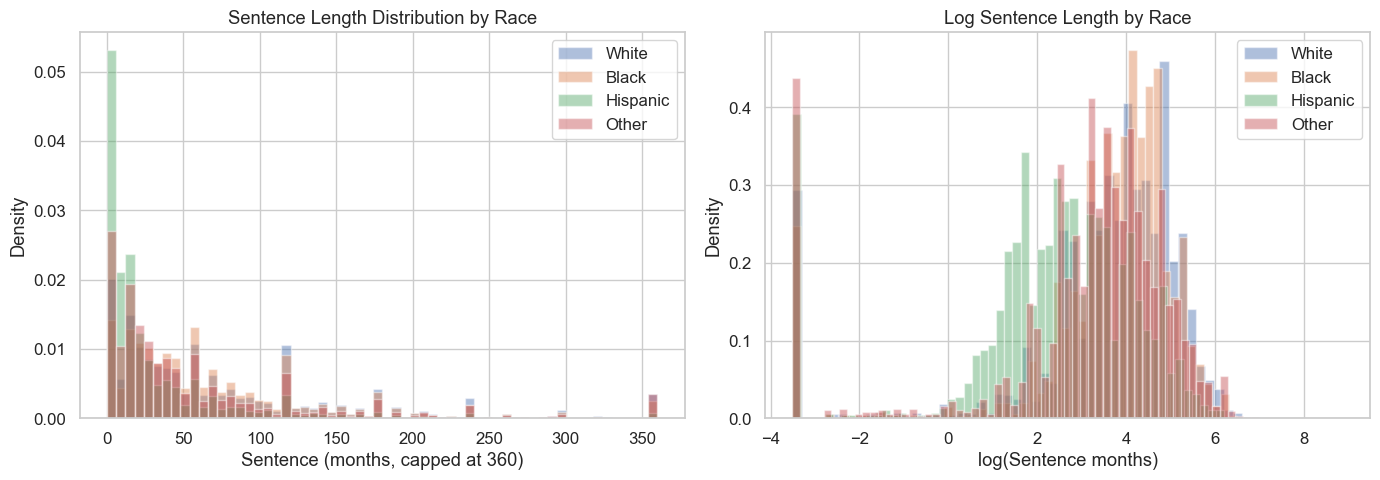

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for race, color in RACE_PALETTE.items():
    sub = df.loc[df['RACE'] == race, 'SENTENCE_MONTHS'].dropna()
    ax.hist(sub.clip(upper=360), bins=60, alpha=0.45, label=race, color=color, density=True)
ax.set_title('Sentence Length Distribution by Race')
ax.set_xlabel('Sentence (months, capped at 360)'); ax.set_ylabel('Density'); ax.legend()

ax = axes[1]
for race, color in RACE_PALETTE.items():
    sub = df.loc[(df['RACE'] == race) & (df['SENTENCE_MONTHS'] > 0), 'SENTENCE_MONTHS'].dropna()
    ax.hist(np.log(sub), bins=60, alpha=0.45, label=race, color=color, density=True)
ax.set_title('Log Sentence Length by Race')
ax.set_xlabel('log(Sentence months)'); ax.set_ylabel('Density'); ax.legend()

fig.tight_layout()
plt.show()

### 5b. Sentence Length Distributions by Sex

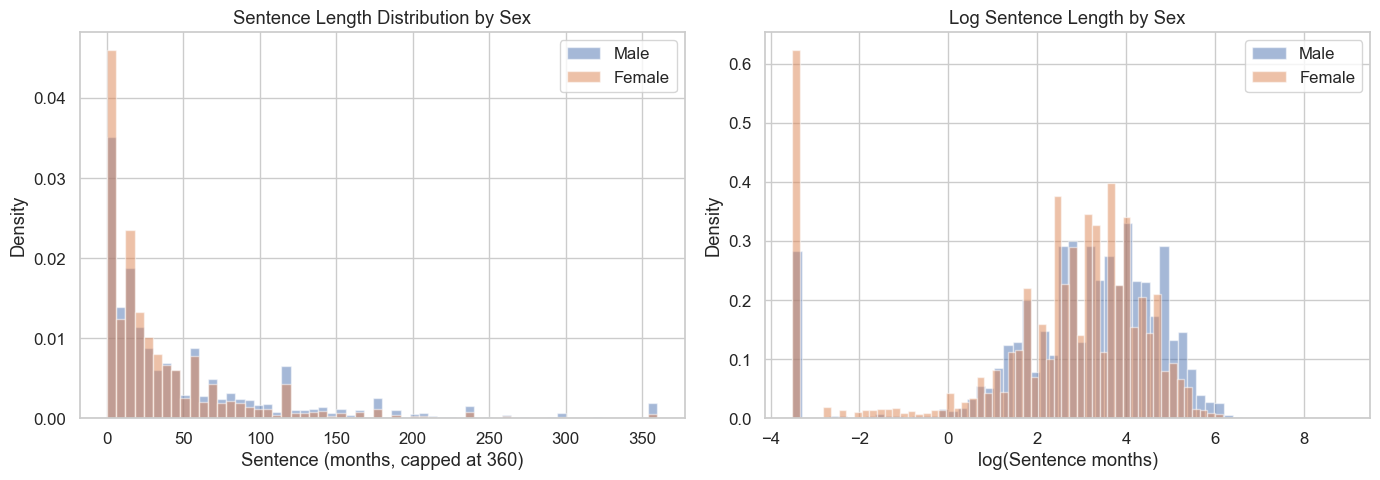

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for sex, color in SEX_PALETTE.items():
    sub = df.loc[df['SEX'] == sex, 'SENTENCE_MONTHS'].dropna()
    ax.hist(sub.clip(upper=360), bins=60, alpha=0.5, label=sex, color=color, density=True)
ax.set_title('Sentence Length Distribution by Sex')
ax.set_xlabel('Sentence (months, capped at 360)'); ax.set_ylabel('Density'); ax.legend()

ax = axes[1]
for sex, color in SEX_PALETTE.items():
    sub = df.loc[(df['SEX'] == sex) & (df['SENTENCE_MONTHS'] > 0), 'SENTENCE_MONTHS'].dropna()
    ax.hist(np.log(sub), bins=60, alpha=0.5, label=sex, color=color, density=True)
ax.set_title('Log Sentence Length by Sex')
ax.set_xlabel('log(Sentence months)'); ax.set_ylabel('Density'); ax.legend()

fig.tight_layout()
plt.show()

### 5c. Box Plots by Offense Category (Top 12)

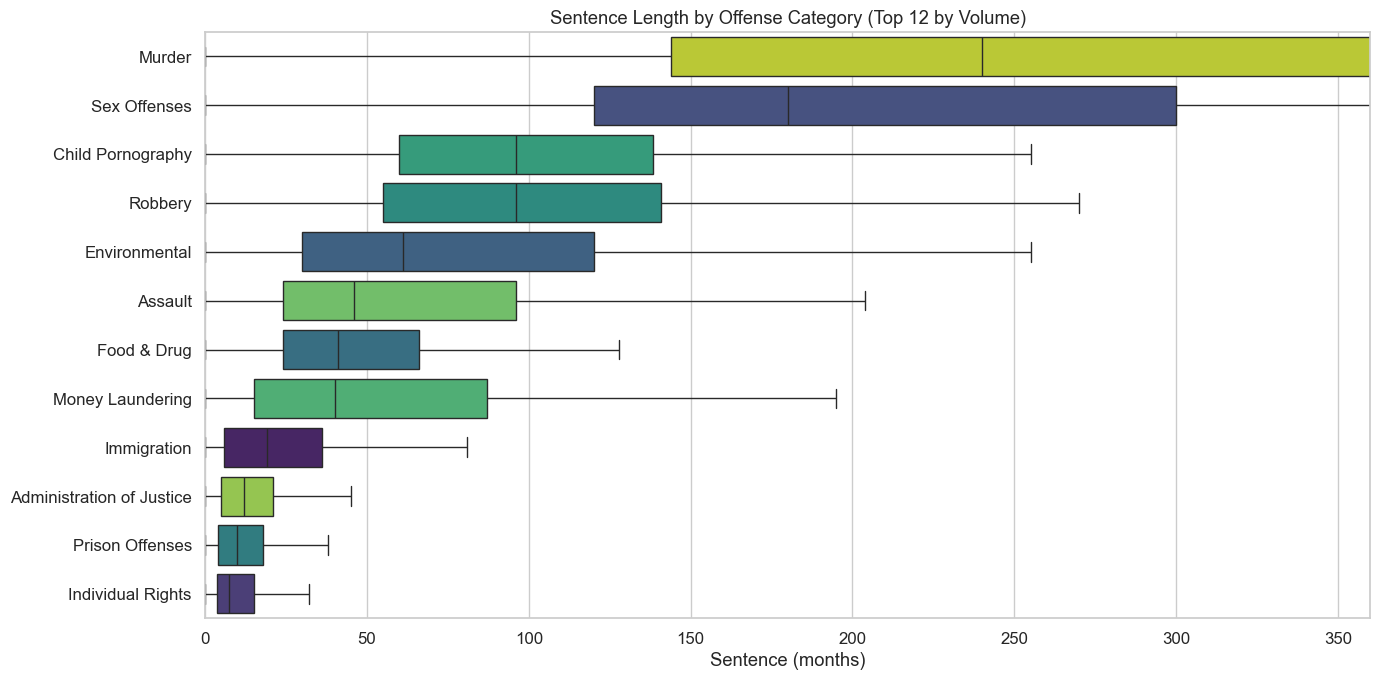

In [19]:
top_cats = df['OFFENSE_CAT'].value_counts().head(12).index.tolist()
sub = df[df['OFFENSE_CAT'].isin(top_cats)].copy()
order = sub.groupby('OFFENSE_CAT')['SENTENCE_MONTHS'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 7))
sns.boxplot(data=sub, y='OFFENSE_CAT', x='SENTENCE_MONTHS', order=order,
            hue='OFFENSE_CAT', palette='viridis', showfliers=False, legend=False, ax=ax)
ax.set_xlim(0, 360)
ax.set_title('Sentence Length by Offense Category (Top 12 by Volume)')
ax.set_xlabel('Sentence (months)'); ax.set_ylabel('')
fig.tight_layout()
plt.show()

### 5d. Box Plots by Race x Sex

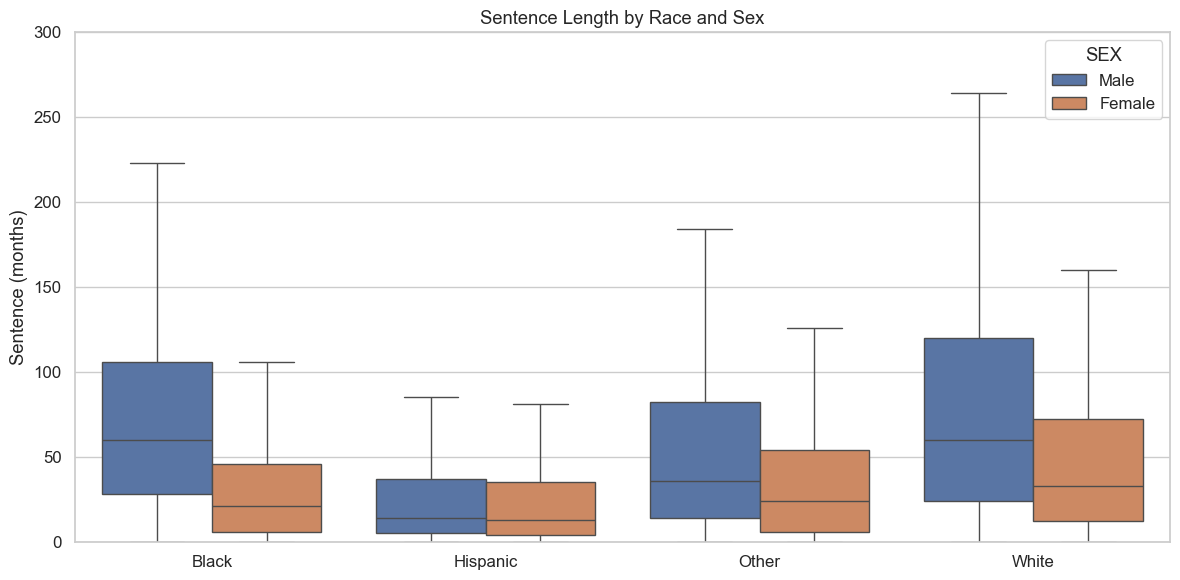

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df, x='RACE', y='SENTENCE_MONTHS', hue='SEX',
            showfliers=False, palette=SEX_PALETTE, ax=ax)
ax.set_ylim(0, 300)
ax.set_title('Sentence Length by Race and Sex')
ax.set_ylabel('Sentence (months)'); ax.set_xlabel('')
fig.tight_layout()
plt.show()

### 5e. Incarceration Rate by Race and Sex

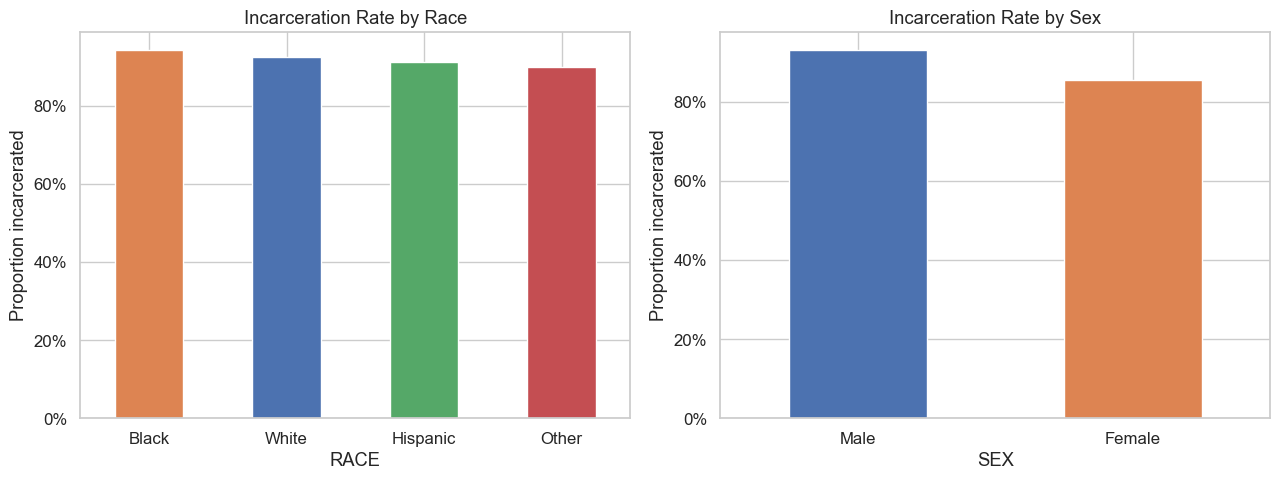

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# By race
ax = axes[0]
rates = df.groupby('RACE')['INCARCERATED'].mean().sort_values(ascending=False)
rates.plot.bar(ax=ax, color=[RACE_PALETTE.get(r, 'grey') for r in rates.index])
ax.set_title('Incarceration Rate by Race')
ax.set_ylabel('Proportion incarcerated')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# By sex
ax = axes[1]
rates = df.groupby('SEX')['INCARCERATED'].mean().sort_values(ascending=False)
rates.plot.bar(ax=ax, color=[SEX_PALETTE.get(s, 'grey') for s in rates.index])
ax.set_title('Incarceration Rate by Sex')
ax.set_ylabel('Proportion incarcerated')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

fig.tight_layout()
plt.show()

### 5f. Log-Transform Justification

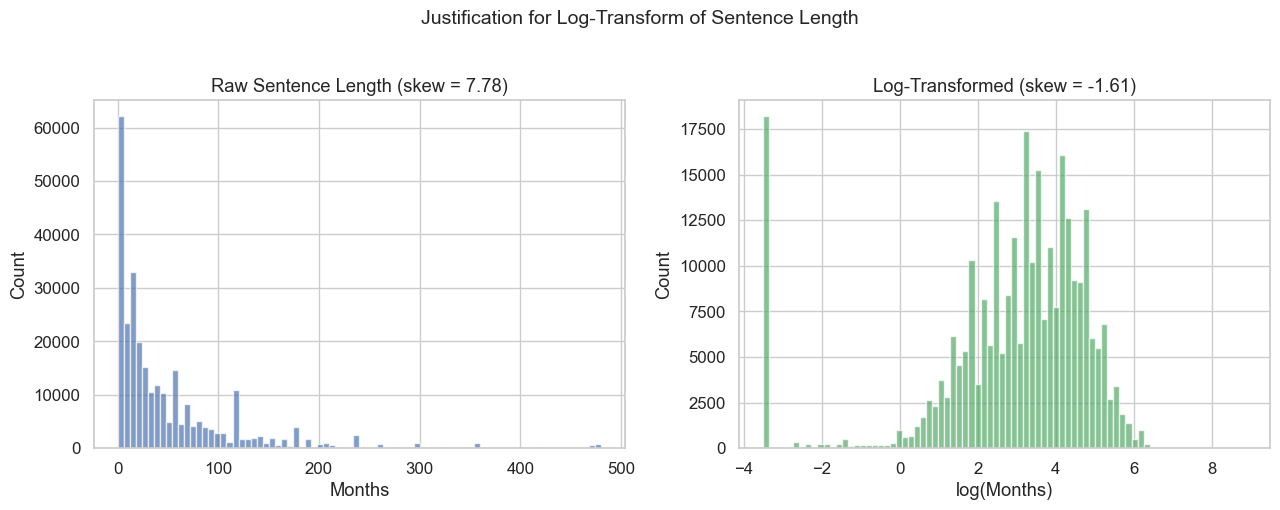

In [22]:
sent = df['SENTENCE_MONTHS'].dropna()
sent_pos = sent[sent > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(sent.clip(upper=480), bins=80, color='#4C72B0', alpha=0.7)
ax.set_title(f'Raw Sentence Length (skew = {sent.skew():.2f})')
ax.set_xlabel('Months'); ax.set_ylabel('Count')

ax = axes[1]
log_s = np.log(sent_pos)
ax.hist(log_s, bins=80, color='#55A868', alpha=0.7)
ax.set_title(f'Log-Transformed (skew = {log_s.skew():.2f})')
ax.set_xlabel('log(Months)'); ax.set_ylabel('Count')

fig.suptitle('Justification for Log-Transform of Sentence Length', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

---
## 6. Save All Tables to CSV

In [23]:
from src.descriptive_stats import run_all
results = run_all(df, save=True)


  DESCRIPTIVE STATISTICS – Sentenced Differently

── Sentence Length by Race ──
          Mean  Median  Std Dev       N
RACE                                   
Black    74.84   56.00    77.68   66067
Hispanic 33.51   14.00    54.11  149612
Other    61.50   33.00    83.55   11421
White    79.04   51.00   100.57   57723

── Sentence Length by Sex ──
        Mean  Median  Std Dev       N
SEX                                  
Female 37.69   20.00    51.46   31668
Male   55.42   30.00    77.89  253155

── Sentence Length by Race × Sex ──
                 Mean  Median  Std Dev       N
RACE     SEX                                  
Black    Female 35.22   21.00    48.50    4901
         Male   78.01   60.00    78.70   61166
Hispanic Female 27.67   13.03    40.22   14399
         Male   34.13   14.00    55.34  135213
Other    Female 40.68   24.00    54.22    2006
         Male   65.94   36.00    87.92    9415
White    Female 52.20   33.00    61.72   10362
         Male   84.91   60.00   106.3

---
## 7. Data Quality Notes

Issues identified during exploration:

1. **Sentence outliers**: `SENTTOT` values 9996+ encode life/death/missing — excluded from continuous analyses.

2. **Missing demographics**: ~27K rows dropped for missing race/sex/sentence (8.7% of raw total). Missingness is primarily in the `NEWRACE` and `MONSEX` fields.

3. **Heavy right skew** (skewness ~ 7.8): Raw sentence distribution has an extremely long right tail. Log-transformation reduces skewness to ~ -1.6 — justifying its use as the DV in regression.

4. **Small 'Other' race group**: Only ~11K cases vs. 57-150K for other groups. Point estimates are less stable.

5. **INOUT variable unreliable**: The prison/probation indicator (`INOUT`) is mostly missing in FY2024 and coded inconsistently across years. We derive `INCARCERATED` from `SENTTOT > 1 month` instead.

6. **Hispanic is the largest group** (52.5%): Reflects the large share of federal immigration cases. Subgroup analysis by offense category is essential to avoid confounding.

7. **Gender imbalance**: Females represent only 11.1% of cases. Sex-stratified analyses have adequate N but lower power for interaction terms.

8. **All tests highly significant**: With N=284K, even small differences reach significance. Effect sizes and practical significance matter more than p-values at this sample size.